Sofia Anaya Palafox

738594

Ingeniería Financiera

Simular 50 posibles trayectorias futuras de una acción de 1 año (252 días hábiles), asumiendo MB

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
S0 = 100    # Precio inicial del activo subyacente
K = 110     # Precio de ejercicio (strike price)
r = 0.05    # Tasa de interés libre de riesgo (5%)
vol = 0.20  # Volatilidad (20%)
T = 1       # Tiempo hasta el vencimiento (1 año)
num_days = 252 # Número de días en el calendario de simulación
num_trajectories = 50 # Número de trayectorias a simular
# Cálculo del paso de tiempo
dt = T / num_days

# Inicialización para almacenar todas las trayectorias
price_trajectories = np.zeros((num_days + 1, num_trajectories))
price_trajectories[0] = S0

# Simulación de Monte Carlo
for i in range(num_trajectories):
    for t in range(1, num_days + 1):
        Z = np.random.standard_normal()
        # Fórmula para el precio S(t)
        price_trajectories[t, i] = price_trajectories[t-1, i] * np.exp((r - 0.5 * vol**2) * dt + vol * np.sqrt(dt) * Z)

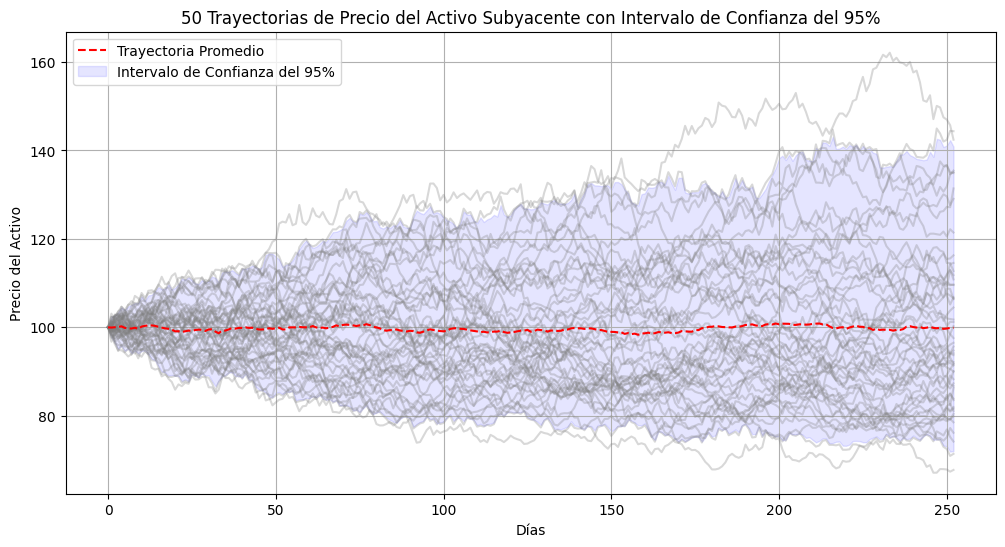

In [5]:
# Graficar las trayectorias
plt.figure(figsize=(12, 6))

# Plotear todas las trayectorias en gris
plt.plot(price_trajectories, color='grey', alpha=0.3)

# Calcular el promedio de las trayectorias
mean_trajectory = np.mean(price_trajectories, axis=1)

# Calcular el intervalo de confianza del 95%
lower_bound = np.percentile(price_trajectories, 2.5, axis=1)
upper_bound = np.percentile(price_trajectories, 97.5, axis=1)

plt.plot(mean_trajectory, color='red', linestyle='--', label='Trayectoria Promedio')

# Rellenar el área del intervalo de confianza del 95%
plt.fill_between(range(num_days + 1), lower_bound, upper_bound, color='blue', alpha=0.1, label='Intervalo de Confianza del 95%')

plt.title('50 Trayectorias de Precio del Activo Subyacente con Intervalo de Confianza del 95%')
plt.xlabel('Días')
plt.ylabel('Precio del Activo')
plt.grid(True)
plt.legend()
plt.show()

In [6]:
import pandas as pd

# Transponer price_trajectories para tener 50 filas (trayectorias) y 253 columnas (días)
transposed_trajectories = price_trajectories.T

# Crear un DataFrame para mostrar una parte de las trayectorias y los límites del CI
data_sample = pd.DataFrame({
    'Día': range(num_days + 1),
    'Trayectoria 1 (Ejemplo)': price_trajectories[:, 0],
    'Trayectoria 2 (Ejemplo)': price_trajectories[:, 1],
    'Límite Inferior CI (2.5%)': lower_bound,
    'Límite Superior CI (97.5%)': upper_bound
})

# Mostrar las primeras y últimas filas del DataFrame
display(data_sample.head())


,Día,Trayectoria 1 (Ejemplo),Trayectoria 2 (Ejemplo),Límite Inferior CI (2.5%),Límite Superior CI (97.5%)
0,0,100.000000,100.000000,100.000000,100.000000
1,1,100.567937,102.342566,97.771214,102.389305
2,2,99.309157,102.397881,96.606149,102.689810
3,3,99.856098,103.447023,95.125452,103.370320
4,4,100.438771,104.679954,95.874267,104.513398


Ahora simular lo mismo pero con 1000 trayectorias y sacando S(T) y S testada

### Simulación con 1000 Trayectorias

In [25]:
# Definir el nuevo número de trayectorias
num_trajectories_1000 = 1000

# Inicialización para almacenar todas las trayectorias
price_trajectories_1000 = np.zeros((num_days + 1, num_trajectories_1000))
price_trajectories_1000[0] = S0

# Simulación de Monte Carlo para 1000 trayectorias
for i in range(num_trajectories_1000):
    for t in range(1, num_days + 1):
        Z = np.random.standard_normal()
        # Fórmula para el precio S(t)
        price_trajectories_1000[t, i] = price_trajectories_1000[t-1, i] * np.exp((r - 0.5 * vol**2) * dt + vol * np.sqrt(dt) * Z)

### Resultados de S(T) y S Ponderada

In [26]:
import pandas as pd
import numpy as np

# Obtener S(T) para cada una de las 1000 trayectorias (el último día de cada columna)
S_T_values = price_trajectories_1000[num_days, :]

# Calcular S ponderada (promedio de S(T)) - este es el promedio general de los valores S(T)
S_ponderada_global_ST = np.mean(S_T_values)

# Calcular el promedio de precio para cada trayectoria a lo largo de su duración
# price_trajectories_1000 tiene forma (días + 1, número de trayectorias)
# np.mean(..., axis=0) calcula el promedio para cada columna (cada trayectoria) a lo largo de las filas (días)
S_ponderada_por_trayectoria = np.mean(price_trajectories_1000, axis=0)

# Crear un DataFrame para la tabla solicitada con las tres columnas
data = {
    'Trayectoria': [f'Trayectoria {i+1}' for i in range(num_trajectories_1000)],
    'S(T)': S_T_values,
    'Promedio de Precio por Trayectoria': S_ponderada_por_trayectoria # El promedio de cada trayectoria
}
results_df = pd.DataFrame(data)

# Añadir una fila para el resumen de los promedios al final del DataFrame para visualización
results_df_display = results_df.copy()
results_df_display.loc['Promedio'] = {
    'Trayectoria': 'RESUMEN',
    'S(T)': S_ponderada_global_ST, # El promedio de S(T) de todas las trayectorias
    'Promedio de Precio por Trayectoria': np.mean(S_ponderada_por_trayectoria) # El promedio de los promedios por trayectoria
}


print(f"El Promedio General de S(T) es: {S_ponderada_global_ST:.2f}")
print("\nTabla de S(T), Promedio General S(T) y Promedio de Precio por Trayectoria:")
display(results_df_display)


El Promedio General de S(T) es: 105.06

Tabla de S(T), Promedio General S(T) y Promedio de Precio por Trayectoria:


,Trayectoria,S(T),Promedio de Precio por Trayectoria
0,Trayectoria 1,103.085006,97.920540
1,Trayectoria 2,80.405463,79.861190
2,Trayectoria 3,110.560213,108.868993
3,Trayectoria 4,79.102319,86.066292
4,Trayectoria 5,101.694769,92.669353
...,...,...,...
996,Trayectoria 997,101.768590,109.471101
997,Trayectoria 998,88.828904,86.078149
998,Trayectoria 999,96.993428,100.631750
999,Trayectoria 1000,114.463439,106.972623


### Histograma de S(T) y Promedio de Precio por Trayectoria

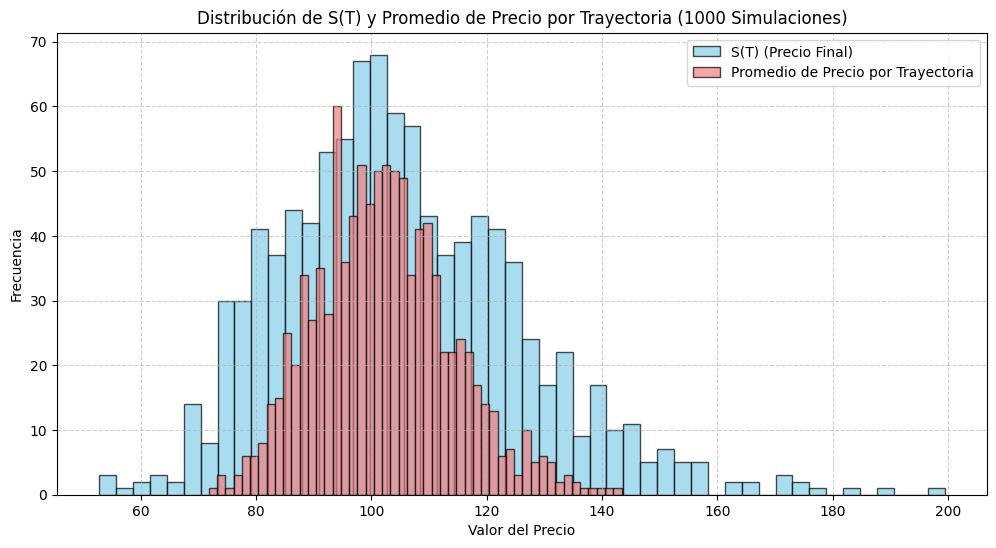

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Histograma para S(T)
plt.hist(S_T_values, bins=50, alpha=0.7, label='S(T) (Precio Final)', color='skyblue', edgecolor='black')

# Histograma para Promedio de Precio por Trayectoria
plt.hist(S_ponderada_por_trayectoria, bins=50, alpha=0.7, label='Promedio de Precio por Trayectoria', color='lightcoral', edgecolor='black')

plt.title('Distribución de S(T) y Promedio de Precio por Trayectoria (1000 Simulaciones)')
plt.xlabel('Valor del Precio')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Cálculo del Payoff Promedio de Opciones Call (Asiática vs. Europea)

In [28]:
# 1. Cálculo del Payoff de la Opción Call Europea
# Payoff para cada trayectoria: max(0, S(T) - K)
payoff_european_call = np.maximum(0, S_T_values - K)

# Valor promedio del payoff de la opción Europea
average_payoff_european = np.mean(payoff_european_call)

# Desviación estándar del payoff de la opción Europea
std_dev_payoff_european = np.std(payoff_european_call* np.exp(-r * T))

# Descontar el promedio del payoff a valor presente
present_value_european = average_payoff_european * np.exp(-r * T)

#  2. Cálculo del Payoff de la Opción Call Asiática
# Para la opción asiática, calculamos el precio promedio de cada trayectoria, excluyendo el primer día (S0)
# price_trajectories_1000 tiene forma (num_days + 1, num_trajectories_1000)
# Seleccionamos desde el segundo día hasta el final: price_trajectories_1000[1:, :]

# Calcular el promedio del precio de cada trayectoria (excluyendo el primer día)
average_price_for_asian_option = np.mean(price_trajectories_1000[1:, :], axis=0)

# Payoff para cada trayectoria asiática: max(0, Precio Promedio - K)
payoff_asian_call = np.maximum(0, average_price_for_asian_option - K)

# Valor promedio del payoff de la opción Asiática
average_payoff_asian = np.mean(payoff_asian_call)

# Desviación estándar del payoff de la opción Asiática
std_dev_payoff_asian = np.std(payoff_asian_call* np.exp(-r * T))

# Descontar el promedio del payoff asiático a valor presente
present_value_asian = average_payoff_asian * np.exp(-r * T)

print(f"Valor Promedio del Payoff (Valor presente) de la Opción Call Europea: {present_value_european:.2f}")
print(f"Desviación Estándar del Payoff de la Opción Call Europea: {std_dev_payoff_european:.2f}")
print(f"Valor Promedio del Payoff (Valor presente) de la Opción Call Asiática: {present_value_asian:.2f}")
print(f"Desviación Estándar del Payoff de la Opción Call Asiática: {std_dev_payoff_asian:.2f}")

Valor Promedio del Payoff (Valor presente) de la Opción Call Europea: 5.93
Desviación Estándar del Payoff de la Opción Call Europea: 11.51
Valor Promedio del Payoff (Valor presente) de la Opción Call Asiática: 1.85
Desviación Estándar del Payoff de la Opción Call Asiática: 4.65
